In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance

#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner
from scripts.feat_eng import apply_all

warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

#싸이킷런에서 인코딩 후 데이터를 판다스 데이터 프레임으로 남기기
set_config(transform_output="pandas")

In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

In [4]:
## 컬럼명 변경
def rename_column(merchant_df, sale_df, cust_df):
    # merchant_df 컬럼명 변경
    merchant_df.columns = ['가맹점 구분번호', '가맹점 주소', '가맹점명', '브랜드 구분코드', '가맹점 지역', '업종', '상권', '개업일', '폐업일']

    # sale_df 컬럼명 변경
    sale_df.columns = ['가맹점 구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', 
                       '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중']
    # cust_df 컬럼명 변경
    cust_df.columns = ['가맹점 구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', 
                       '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중','재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']
    
    return merchant_df, sale_df, cust_df

rename_column(merchant_df, sale_df, cust_df)

(        가맹점 구분번호               가맹점 주소          가맹점명   브랜드 구분코드  가맹점 지역  \
 0     16184E93D9           서울 성동구 마장동          성우**        NaN  서울 성동구   
 1     4D039EA8B7           서울 성동구 마장동          대보**        NaN  서울 성동구   
 2     0074C4990A           서울 성동구 마장동          대용**        NaN  서울 성동구   
 3     68308F2746           서울 성동구 마장동          통일**        NaN  서울 성동구   
 4     4117EDDE9C           서울 성동구 마장동          한울**        NaN  서울 성동구   
 ...          ...                  ...           ...        ...     ...   
 4180  7FCF23E6F3    서울특별시 성동구 마장로 137  아이**********        NaN  서울 성동구   
 4181  9743B78531      서울 성동구 독서당로 223          어반**        NaN  서울 성동구   
 4182  C2261977A8  서울특별시 성동구 마장로35길 76          한성**        NaN  서울 성동구   
 4183  F1C69918DF      서울 성동구 왕십리로 410          국수**  한식-국수/만두3  서울 성동구   
 4184  58B8C943BF     서울특별시 성동구 매봉길 50      아이******        NaN  서울 성동구   
 
             업종   상권       개업일  폐업일  
 0          축산물  마장동  20130320  NaN  
 1          축산물  마장동  

In [5]:
## 가맹점 데이터 전처리
def preprocess_merchant(merchant_df):
    # 복사본 생성
    merchant_df_prc = merchant_df.copy()

    #개업일 자료형을 숫자에서 날짜형으로 변환
    merchant_df_prc['폐업 여부'] = merchant_df_prc['폐업일'].notna().astype(int)
    merchant_df_prc['개업일'] = pd.to_datetime(merchant_df_prc['개업일'],format="%Y%m%d") #개업일 날짜형으로 변환

    merchant_df_prc['폐업일'] = merchant_df_prc['폐업일'].fillna(20250901) #폐업일을 2025년 9월 1일로 채움
    merchant_df_prc['폐업일'] = pd.to_datetime(merchant_df_prc['폐업일'],format="%Y%m%d") #폐업일 날짜형으로 변환
    
    merchant_df_prc['개업 기간'] = (merchant_df_prc['폐업일'] - merchant_df_prc['개업일']).dt.days #개업 기간 기준을 2025년 9월 1일까지로 정함 - 정말로 필요한 데이터일까?
    
    
    ## 업종 그룹화 
    
    meat = ['한식-육류/고기',  '꼬치구이']
    cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
    k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
    w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
    j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
    c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
    drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
    product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
    enter = ['일반 유흥주점',  '룸살롱/단란주점']
    convenience = ['샌드위치/토스트',  '도시락', '분식']
    world_food = ['동남아/인도음식',  '기타세계요리']
    dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
    others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품', '건강원', '담배',  '식료품']
    
    # replace 진행
    groups_to_replace = [(meat, '육류'), (cafe, '카페'), (k_food, '한식'), (w_food, '양식'), (j_food, '일식'),
                         (c_food, '중식'), (drink, '주점'), (product, '농수축산물'), (enter, '유흥업소'), (convenience, '간편식'),
                         (world_food, '이색요리'), (dessert, '디저트'), (others, '기타')]
    
    replacement = {}
    for ind, cat in groups_to_replace:
        for i in ind:
            replacement[i] = cat

    merchant_df_prc['업종'].replace(replacement, inplace=True)

    ## 상권 그룹화
    # 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
    areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                        '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                        '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}
    
    merchant_df_prc['상권'].replace(areas_to_replace, inplace=True)
    
    # 상권 결측치는 Unknown으로 대체
    merchant_df_prc['상권'].fillna('Unknown', inplace=True)
       
    return merchant_df_prc

merchant_df_prc = preprocess_merchant(merchant_df)
merchant_df_prc['개업 기간']

0       4548
1       4301
2       4130
3       3569
4       3552
        ... 
4180     742
4181    4563
4182     838
4183    1425
4184     913
Name: 개업 기간, Length: 4185, dtype: int64

In [6]:
merchant_df_prc

,가맹점 구분번호,가맹점 주소,가맹점명,브랜드 구분코드,가맹점 지역,업종,상권,개업일,폐업일,폐업 여부,개업 기간
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,농수축산물,마장동,2013-03-20,2025-09-01,0,4548
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,농수축산물,마장동,2013-11-22,2025-09-01,0,4301
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,농수축산물,마장동,2014-05-12,2025-09-01,0,4130
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,농수축산물,마장동,2015-11-24,2025-09-01,0,3569
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,농수축산물,마장동,2015-12-11,2025-09-01,0,3552
...,...,...,...,...,...,...,...,...,...,...,...
4180,7FCF23E6F3,서울특별시 성동구 마장로 137,아이**********,NaN,서울 성동구,디저트,Unknown,2023-08-21,2025-09-01,0,742
4181,9743B78531,서울 성동구 독서당로 223,어반**,NaN,서울 성동구,양식,Unknown,2013-03-05,2025-09-01,0,4563
4182,C2261977A8,서울특별시 성동구 마장로35길 76,한성**,NaN,서울 성동구,농수축산물,Unknown,2023-05-17,2025-09-01,0,838
4183,F1C69918DF,서울 성동구 왕십리로 410,국수**,한식-국수/만두3,서울 성동구,한식,Unknown,2021-10-07,2025-09-01,0,1425


In [7]:
merged_df = sale_df.merge(cust_df, on=['가맹점 구분번호','기준년월'])

def preprocess_merged(merged_df):
    # 복사본 생성
    merged_df_prc = merged_df.copy()

    # 구간 데이터 앞에 숫자만 빼오기
    merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'] = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].apply(lambda x: x.str.split('_', expand=True)[0])
    
    # 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
    # 가정: 결측값의 경우 취소율이 적다고 판단!!
    band_cols = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].columns
    merged_df_prc[band_cols] =  merged_df_prc[band_cols].apply(pd.to_numeric,errors='coerce')
    
    ## 비율 데이터 전처리
    # 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
    merged_df_prc['배달매출금액 비율'] = merged_df_prc['배달매출금액 비율'].map(lambda x: 0 if x < 0 else x)

    # 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
    merged_df_prc['동일 상권 내 해지 가맹점 비중'] = merged_df_prc['동일 상권 내 해지 가맹점 비중'].map(lambda x: 0 if x < 0 else x)

    # 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
    # 가정: 결측값의 경우 취소율이 적다고 판단!!
    band_cols = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].columns
    merged_df_prc[band_cols] = merged_df_prc[band_cols].replace(-999999.9,np.nan)

    # 결측치는 0으로 대체
    cust_cols = merged_df_prc.iloc[:, 15:].columns
    merged_df_prc[cust_cols] = merged_df_prc[cust_cols].replace(-999999.9,np.nan)

    # 방문 비율 100%로 맞춤
    merged_df_prc['방문 총합'] =  (merged_df_prc['재방문 고객 비중'] + merged_df_prc['신규 고객 비중'])
    merged_df_prc['재방문 고객 비중'] = 100*merged_df_prc['재방문 고객 비중']/merged_df_prc['방문 총합']
    merged_df_prc['신규 고객 비중'] = 100*merged_df_prc['신규 고객 비중']/merged_df_prc['방문 총합']
    merged_df_prc = merged_df_prc.drop(columns = ['방문 총합'])

    #기준년월 날짜형으로 변환
    merged_df_prc['기준년월'] = pd.to_datetime(merged_df_prc['기준년월'],format="%Y%m")
    # cust_df_prc 데이터 merged_df에 추가

    #취소율 구간 행 제거
    merged_df_prc = merged_df_prc.drop(columns=['취소율 구간'])
    
    return merged_df_prc

merged_df_prc = preprocess_merged(merged_df)

In [8]:
merged_df_prc

,가맹점 구분번호,기준년월,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중,남성 20대이하 고객 비중,남성 30대 고객 비중,남성 40대 고객 비중,남성 50대 고객 비중,남성 60대이상 고객 비중,여성 20대이하 고객 비중,여성 30대 고객 비중,여성 40대 고객 비중,여성 50대 고객 비중,여성 60대이상 고객 비중,재방문 고객 비중,신규 고객 비중,거주 이용 고객 비율,직장 이용 고객 비율,유동인구 이용 고객 비율
0,000F03E44A,2024-04-01,4,5,5,5,5,0.0,2.6,10.6,93.8,71.5,16.7,7.8,18.1818,9.0909,9.0909,18.1818,27.2727,4.0182,2.0091,2.0091,4.0182,6.0273,10.000000,90.000000,12.5,12.5,75.0
1,000F03E44A,2023-12-01,4,6,6,6,6,0.0,0.0,0.0,94.8,73.4,16.6,7.2,12.5083,37.4500,0.0000,24.9417,0.0000,4.1917,12.5500,0.0000,8.3583,0.0000,NaN,NaN,NaN,NaN,NaN
2,002816BA73,2024-04-01,2,3,4,4,2,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5.4384,23.6488,20.0232,22.8248,10.4648,1.1616,5.0512,4.2768,4.8752,2.2352,63.528010,36.471990,23.8,23.8,52.4
3,002816BA73,2024-11-01,2,3,4,4,2,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5.4855,18.9210,21.6240,20.5110,12.9585,1.4145,4.8790,5.5760,5.2890,3.3415,62.298025,37.701975,11.5,11.5,76.9
4,002816BA73,2024-06-01,2,4,4,4,2,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5.3760,22.8480,21.0840,23.9400,10.7520,1.0240,4.3520,4.0160,4.5600,2.0480,67.766323,32.233677,13.0,17.4,69.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86585,A2D9C941A9,2023-04-01,5,2,1,1,6,2.6,249.7,465.0,10.2,0.0,11.4,0.0,10.2828,12.2221,11.6358,7.3513,3.5629,12.5172,14.8779,14.1642,8.9487,4.3371,81.013842,18.986158,71.3,4.3,24.4
86586,A7C2307794,2023-03-01,2,2,2,2,3,19.2,196.7,198.8,10.1,14.1,15.9,8.8,6.4875,13.0269,11.8332,11.3142,9.1863,6.0125,12.0731,10.9668,10.4858,8.5137,68.794579,31.205421,36.8,7.4,55.9
86587,BF6A6456AB,2024-07-01,6,2,4,4,1,1.6,176.3,48.7,11.5,16.5,19.1,8.7,5.4023,24.6442,9.0443,13.2326,8.4373,3.4977,15.9558,5.8557,8.5674,5.4627,58.499038,41.500962,16.7,41.7,41.7
86588,C59F032CAC,2024-06-01,1,2,2,2,4,24.0,116.5,74.5,26.6,30.2,12.3,10.9,27.3456,13.6728,8.6184,11.7288,3.4344,14.8544,7.4272,4.6816,6.3712,1.8656,78.586957,21.413043,40.0,11.3,48.7


In [9]:
recent3 = merged_df_prc.sort_values(by=['기준년월']).groupby('가맹점 구분번호').tail(3)
result_df = recent3.groupby('가맹점 구분번호').mean(numeric_only=True).reset_index()

band_cols = result_df.loc[:, '가맹점 운영개월수 구간':'객단가 구간'].columns
for i in band_cols:
    result_df[i] = result_df[i].round(0)

result_df

,가맹점 구분번호,가맹점 운영개월수 구간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,동일 상권 내 해지 가맹점 비중,남성 20대이하 고객 비중,남성 30대 고객 비중,남성 40대 고객 비중,남성 50대 고객 비중,남성 60대이상 고객 비중,여성 20대이하 고객 비중,여성 30대 고객 비중,여성 40대 고객 비중,여성 50대 고객 비중,여성 60대이상 고객 비중,재방문 고객 비중,신규 고객 비중,거주 이용 고객 비율,직장 이용 고객 비율,유동인구 이용 고객 비율
0,000F03E44A,4.0,6.0,5.0,5.0,5.0,74.233333,1.066667,3.000000,86.966667,62.666667,17.266667,9.100000,13.565200,11.052600,6.056900,14.100000,11.587400,10.501467,8.547400,4.676433,10.900000,8.945933,64.157598,35.842402,22.233333,8.333333,69.433333
1,002816BA73,2.0,3.0,4.0,4.0,2.0,0.000000,104.400000,53.966667,18.300000,19.933333,16.733333,6.466667,5.753333,19.416633,21.171767,20.641767,12.889867,1.446667,4.883367,5.328233,5.191567,3.243467,58.111298,41.888702,16.966667,6.133333,76.833333
2,003473B465,3.0,6.0,6.0,6.0,6.0,0.000000,0.000000,0.000000,95.700000,88.033333,16.800000,9.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,003AC99735,3.0,2.0,1.0,1.0,6.0,1.600000,273.366667,521.633333,3.500000,9.666667,15.400000,7.766667,14.444133,17.388967,11.358867,12.120067,4.787967,9.589200,11.544367,7.541133,8.046600,3.178700,86.862279,13.137721,36.366667,10.700000,52.900000
4,0041E4E5AE,3.0,2.0,2.0,2.0,4.0,9.933333,217.033333,427.200000,8.366667,9.166667,17.933333,7.766667,13.872100,15.479900,12.719800,17.999900,11.904300,5.394567,6.020100,4.946867,7.000100,4.629033,81.404579,18.595421,27.100000,11.766667,61.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4180,FFAC8CC0F7,1.0,6.0,6.0,6.0,5.0,33.333333,0.300000,0.500000,43.533333,37.100000,16.733333,8.033333,13.780667,20.419833,11.122867,13.709800,16.333500,4.486000,6.680167,3.610467,4.490200,5.366500,99.375951,0.624049,NaN,NaN,NaN
4181,FFD5654C3D,2.0,3.0,3.0,2.0,3.0,2.000000,136.733333,244.200000,13.400000,30.100000,17.933333,11.700000,25.235200,11.670267,10.379767,10.742467,2.479200,16.498133,7.629733,6.786900,7.024200,1.620800,71.304198,28.695802,39.900000,14.100000,46.000000
4182,FFE9F1CC6A,6.0,4.0,4.0,4.0,4.0,0.000000,119.950000,62.700000,68.000000,63.750000,17.550000,7.800000,13.157200,7.407400,12.328400,12.328400,6.578600,12.242800,6.892600,11.471600,11.471600,6.121400,5.713747,94.286253,47.600000,12.700000,39.700000
4183,FFEDAC5747,3.0,1.0,1.0,1.0,5.0,9.033333,267.733333,334.766667,5.200000,0.000000,14.933333,0.000000,5.646100,8.974533,12.710133,8.552933,6.249633,7.753900,12.325467,17.456533,11.747067,8.583700,87.484170,12.515830,64.733333,8.400000,26.866667


In [10]:
final_df = merchant_df_prc.merge(result_df, on ='가맹점 구분번호')

In [11]:
def get_top3_info(row): #단골 고객층, 단골 고객층 합계 집계 함수

    non_zero_scores = row[row > 0]

    top_scores = non_zero_scores.nlargest(3)
    
    top_cols = top_scores.index.tolist()
    top_cols = [column.replace(' 고객 비중', '') for column in top_cols]
    top_sum = top_scores.sum()
    
    return pd.Series([top_cols, top_sum], index=['단골 고객층 탑3', '단골 고객층 합계'])

cus_age = result_df.loc[:, '남성 20대이하 고객 비중':'여성 60대이상 고객 비중'].columns
final_df[['단골 고객층 탑3', '단골 고객층 합계']] = final_df[cus_age].apply(get_top3_info, axis=1)



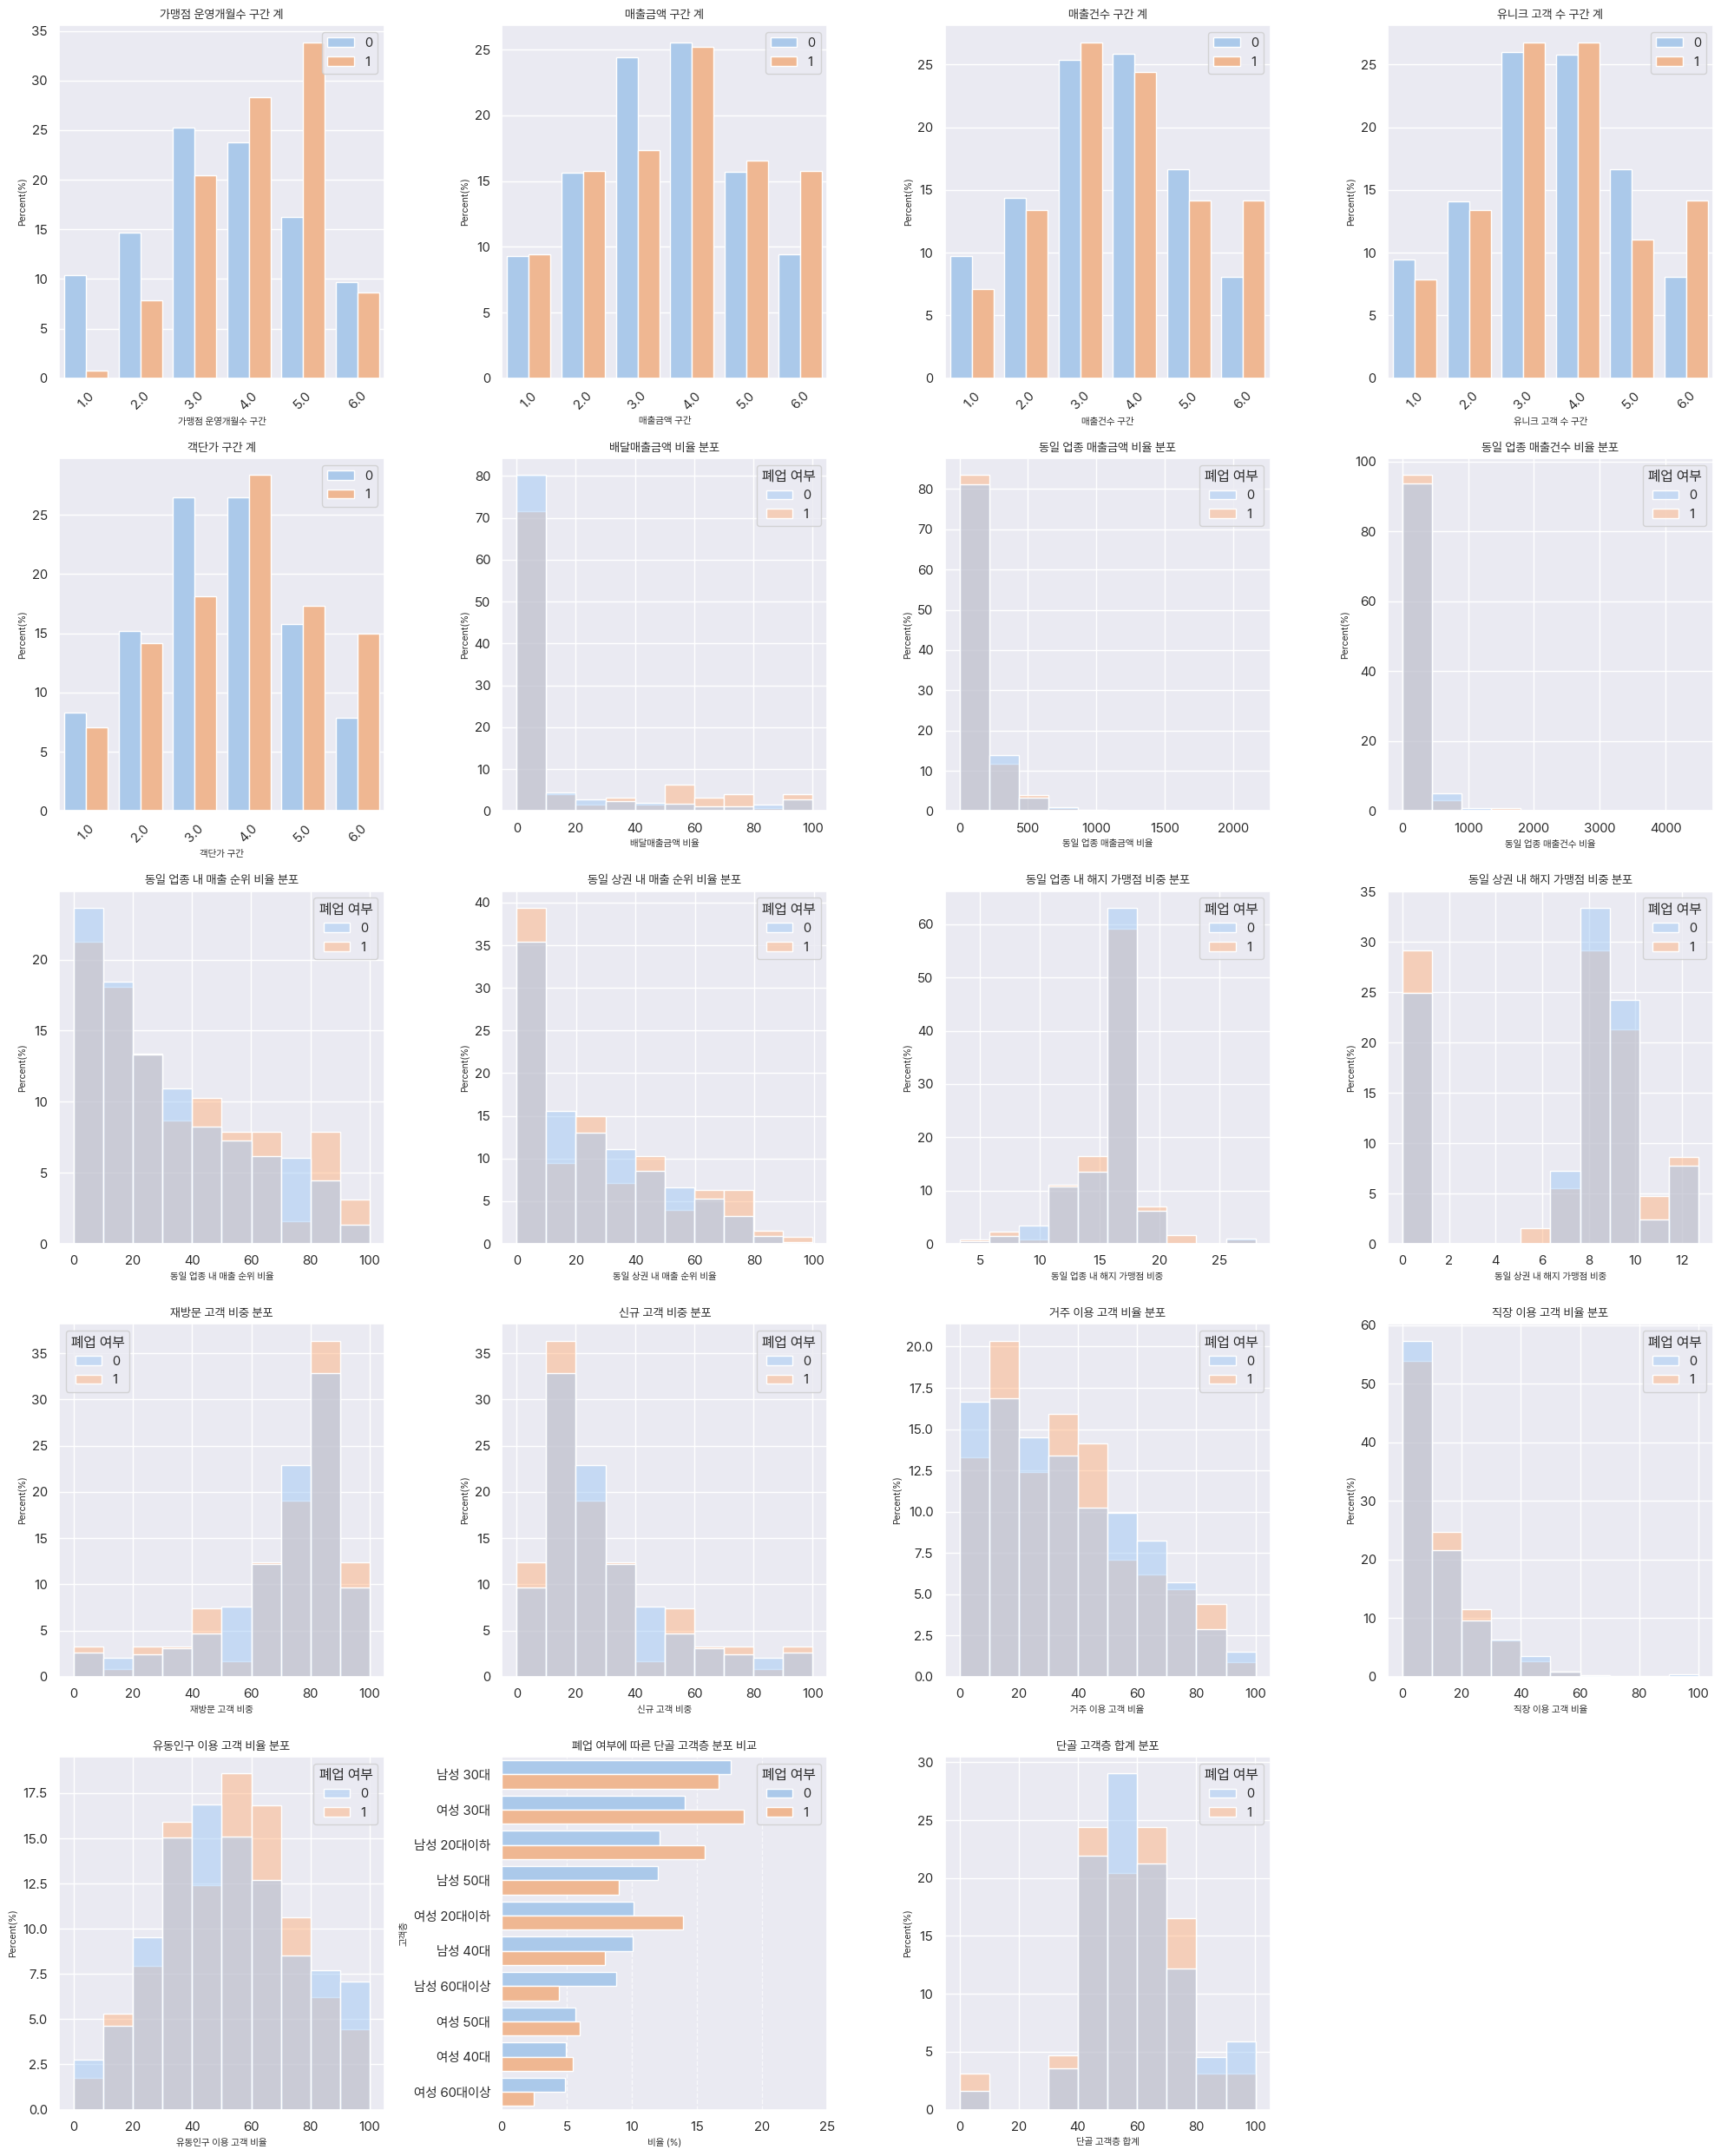

In [12]:
import math
columns_name = [ '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간',
       '유니크 고객 수 구간', '객단가 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '재방문 고객 비중','신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율','단골 고객층 탑3','단골 고객층 합계']

num_plots = len(columns_name)
ncols = 4  
nrows = math.ceil(num_plots / ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows)) 
axes = axes.flatten()


for idx, column in enumerate(columns_name):
    ax = axes[idx]
    
    if column == '단골 고객층 탑3':

        exploded_df = final_df.explode('단골 고객층 탑3').rename(columns={'단골 고객층 탑3': '고객층'})
        counts_df = exploded_df.groupby(['폐업 여부', '고객층']).size().reset_index(name='counts')
        total_counts = counts_df.groupby('폐업 여부')['counts'].transform('sum')
        counts_df['percentage'] = (counts_df['counts'] / total_counts) * 100
        sns.barplot(data=counts_df,y='고객층',x='percentage',hue='폐업 여부',order=exploded_df['고객층'].value_counts().index,ax=ax)
        ax.set_title('폐업 여부에 따른 단골 고객층 분포 비교', fontsize=10)
        ax.set_xlabel('비율 (%)', fontsize=8)
        ax.set_ylabel('고객층', fontsize=8)
        ax.set_xlim(0, 25) # x축 범위 설정으로 가독성 확보
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        ax.legend(loc = 'upper right',title='폐업 여부')


    elif idx > 4:
        sns.histplot(x = column,hue = '폐업 여부', data = final_df,stat='percent',common_norm=False,bins = 10, ax=ax)
        ax.set_title(f'{column} 분포', fontsize=10)
        ax.set_xlabel(column, fontsize=8)
        ax.set_ylabel('Percent(%)', fontsize=8)
        #ax.legend(loc = 'upper right')
    else:
        counts_df = final_df.groupby([column,'폐업 여부']).size().unstack(fill_value=0)
        normalized_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100
        plot_data = normalized_df.stack().reset_index(name='percent')

        sns.barplot(x = column,y='percent',hue = '폐업 여부', data = plot_data,errwidth=0,orient='v', ax=ax)
        ax.set_title(f'{column} 계', fontsize=10)
        ax.set_xlabel(column, fontsize=8)
        ax.set_ylabel('Percent(%)', fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc = 'upper right')

for idx in range(num_plots, nrows * ncols):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

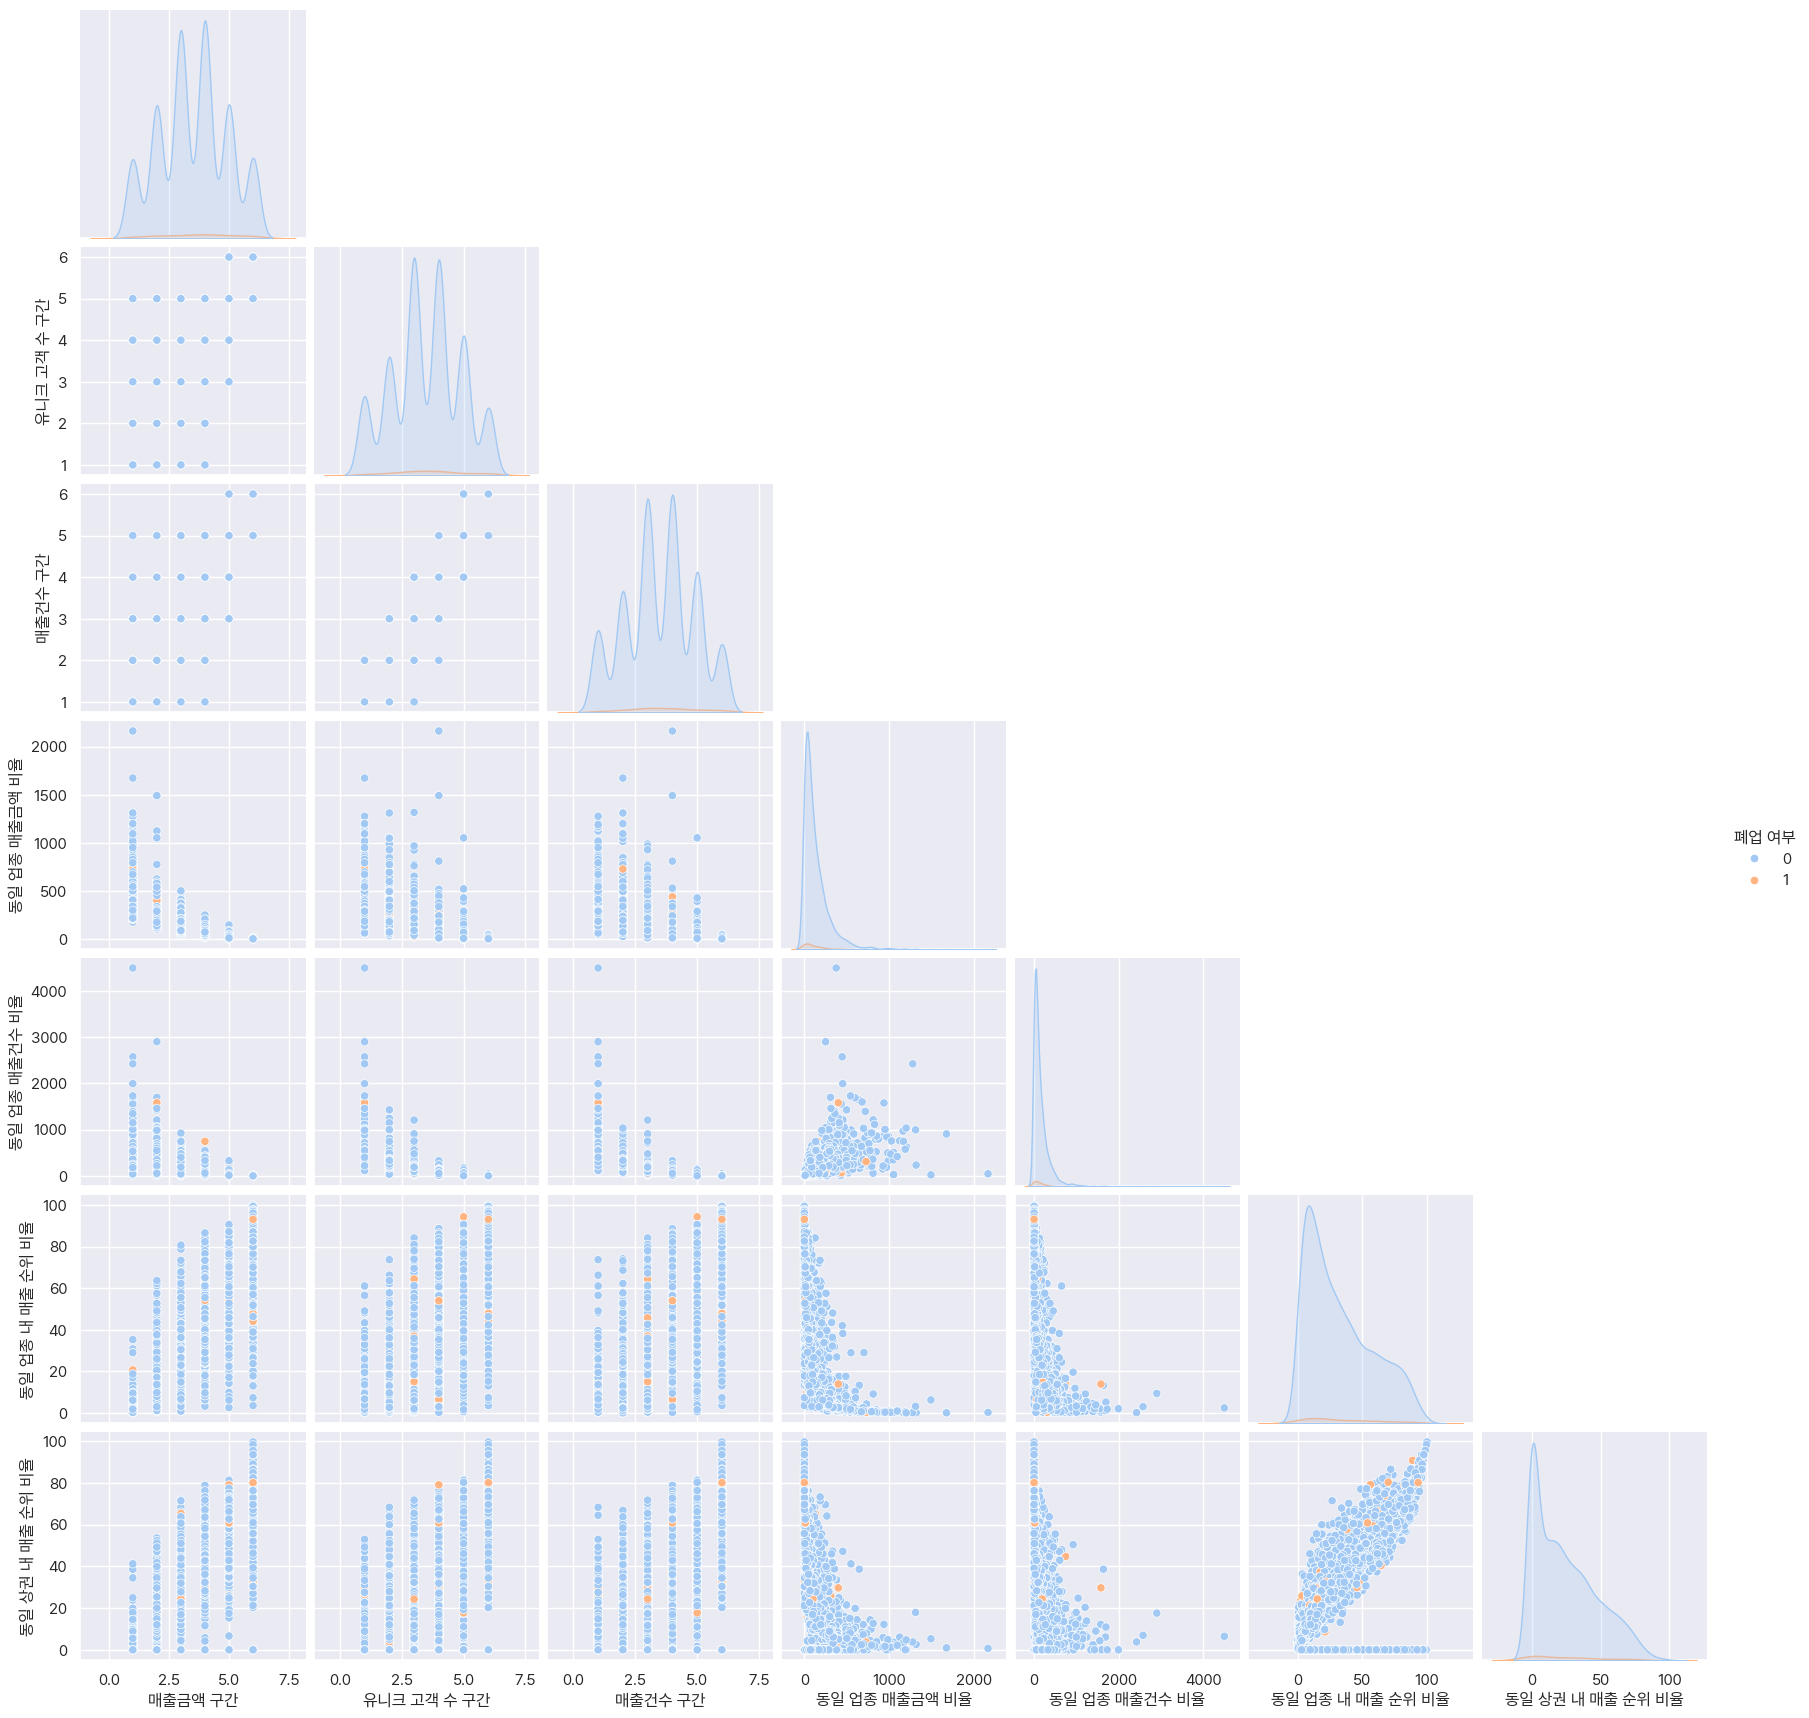

In [13]:

columns_name = [ '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간',
       '유니크 고객 수 구간', '객단가 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '재방문 고객 비중','신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']

selected_columns = ['매출금액 구간',
    '유니크 고객 수 구간','매출건수 구간' ,'동일 업종 매출금액 비율','동일 업종 매출건수 비율','동일 업종 내 매출 순위 비율','동일 상권 내 매출 순위 비율', 
     
    '폐업 여부' 
]

sns.pairplot(final_df[selected_columns], hue='폐업 여부', corner=True)
plt.show()